# 📊 Data Science with Python Internship – Task 3

## Mini Exploratory Data Analysis (EDA) on Titanic Dataset

### Objectives
- Clean the dataset
- Handle missing values
- Perform exploratory data analysis (EDA)
- Visualize important insights using charts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Load Dataset

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Explore Dataset

In [3]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning

In [4]:
# Fill missing Age values
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill missing Embarked values
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column
df = df.drop(columns=['Cabin'])

# Check missing values
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Feature Engineering

In [5]:
# Family Size
df['FamilySize'] = df['SibSp'] + df['Parch']

# Age Groups
bins = [0,12,18,35,60,100]
labels = ['Child','Teen','Young Adult','Adult','Senior']

df['AgeGroup'] = pd.cut(df['Age'],
                        bins=bins,
                        labels=labels)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,Young Adult


## Survival Rate by Age Group

AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


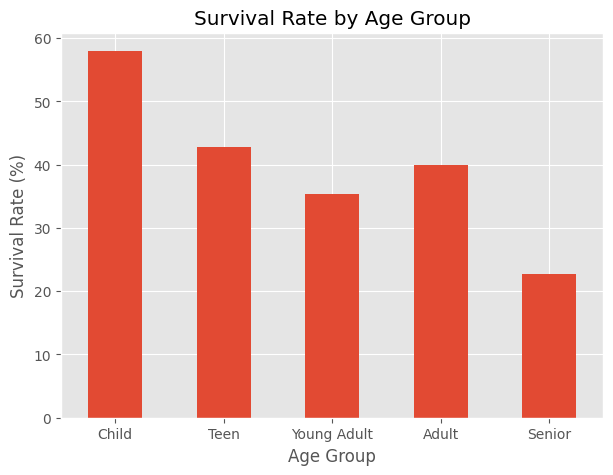

In [6]:
age_survival = df.groupby('AgeGroup')['Survived'].mean()*100

print(age_survival)

age_survival.plot(kind='bar', figsize=(7,5))

plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate (%)")
plt.xlabel("Age Group")
plt.xticks(rotation=0)

plt.show()

### Insight

Young adults had the highest number of survivors, while seniors had the lowest survival rate.

## Survival Rate by Embarkation Port

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


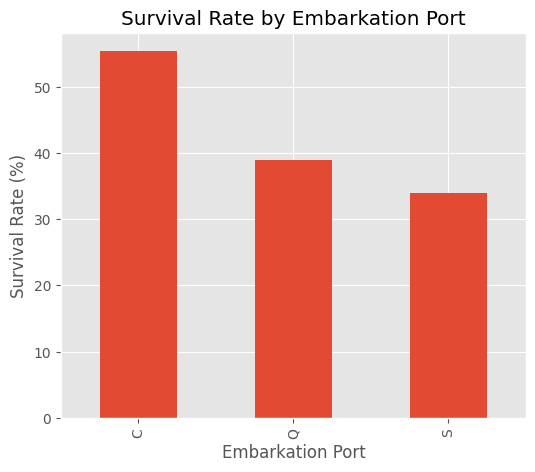

In [7]:
embarked_survival = df.groupby('Embarked')['Survived'].mean()*100

print(embarked_survival)

embarked_survival.plot(kind='bar', figsize=(6,5))

plt.title("Survival Rate by Embarkation Port")
plt.ylabel("Survival Rate (%)")
plt.xlabel("Embarkation Port")

plt.show()

### Insight

Passengers boarding from different ports had different survival rates.

## Survival Rate by Family Size

FamilySize
0     30.353818
1     55.279503
2     57.843137
3     72.413793
4     20.000000
5     13.636364
6     33.333333
7      0.000000
10     0.000000
Name: Survived, dtype: float64


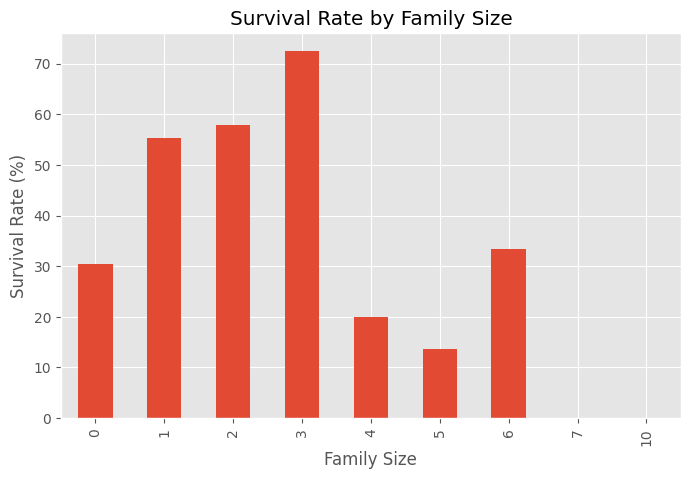

In [9]:
family_survival = df.groupby('FamilySize')['Survived'].mean()*100

print(family_survival)

family_survival.plot(kind='bar', figsize=(8,5))

plt.title("Survival Rate by Family Size")
plt.ylabel("Survival Rate (%)")
plt.xlabel("Family Size")

plt.show()

### Insight

Passengers travelling with a small family generally had better survival rates than those travelling alone or with very large families.

## Age Distribution

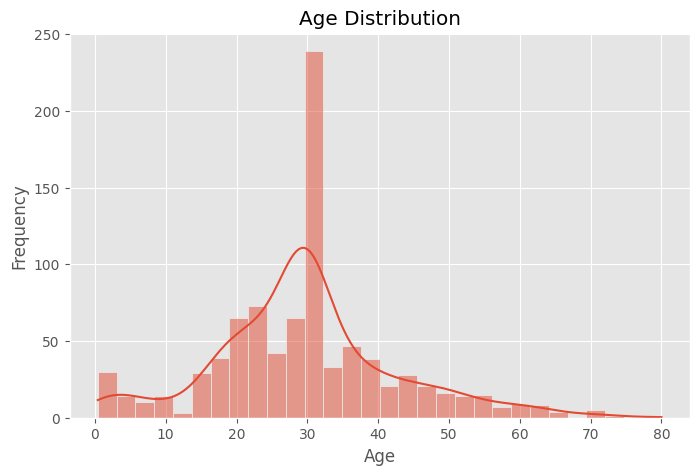

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

### Insight

Most passengers were between 20 and 40 years old.

## Correlation Heatmap

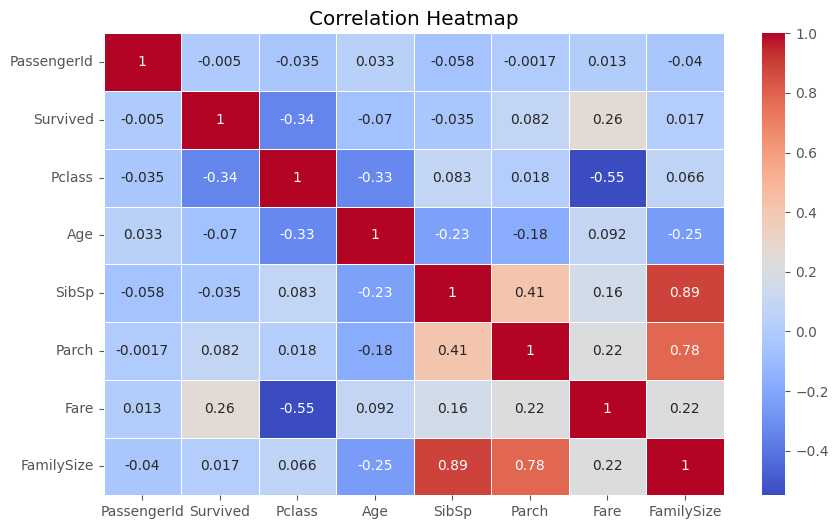

In [11]:
plt.figure(figsize=(10,6))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

### Insight

Passenger class showed a negative correlation with survival, while fare had a positive correlation with survival.

## Additional Visualization: Survival Count

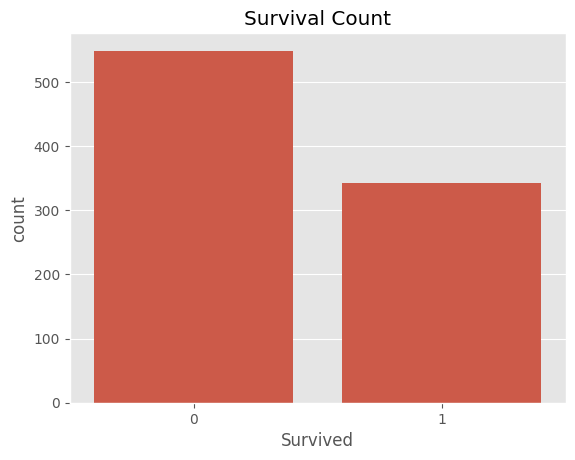

In [12]:
sns.countplot(x='Survived', data=df)

plt.title("Survival Count")

plt.show()

### Insight

The dataset contains more non-survivors than survivors.

## Additional Visualization: Survival by Gender

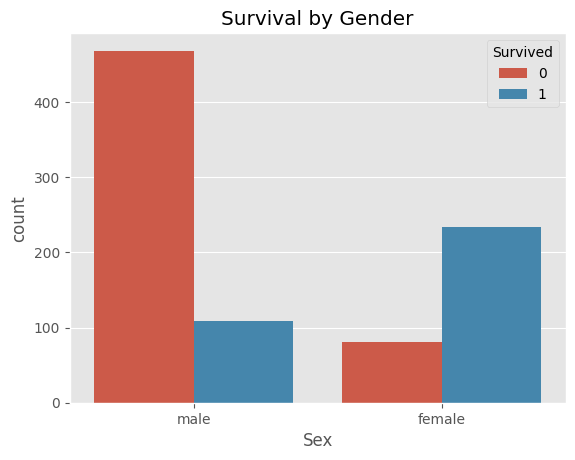

In [14]:
sns.countplot(x='Sex',
              hue='Survived',
              data=df)

plt.title("Survival by Gender")

plt.show()

### Insight

Female passengers had a much higher survival rate than male passengers.

# Conclusion

This exploratory data analysis involved cleaning the Titanic dataset, handling missing values, engineering new features, and exploring relationships using visualizations.

Key findings include:

- Most passengers were young adults.
- Females had significantly higher survival rates.
- Passenger class influenced survival.
- Smaller families generally had higher survival rates.
- Fare was positively correlated with survival.

This analysis demonstrates how EDA can reveal meaningful patterns before applying machine learning models.